In [2]:
#!/usr/bin/env python3
"""
Train an AutoInt model on Moltbook data using pytorch_tabular.
Uses R² as the primary evaluation metric.
"""

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt
import joblib
import warnings
warnings.filterwarnings('ignore')

from pytorch_tabular import TabularModel
from pytorch_tabular.models import AutoIntConfig
from pytorch_tabular.config import DataConfig, OptimizerConfig, TrainerConfig

# ==========================================
# CONFIGURATION
# ==========================================

from google.colab import drive
drive.mount('/content/drive')
DESTINATION_DIR = '/content/drive/MyDrive/Colab Notebooks/data/cds'
DATA_PATH = f"{DESTINATION_DIR}/processed_v1_5_4_new_full.pkl"
EMBEDDING_COL = "embeddings"
TARGET_COL = "score"
RANDOM_STATE = 42
TEST_SIZE = 0.30
VAL_SIZE_FROM_TEMP = 0.50
DROP_COLS = ["safe_content", "content", "id"]

# ==========================================
# 1. Load and prepare data (same as before)
# ==========================================
print("Loading data...")
moltbook = pd.read_pickle(DATA_PATH)
print(f"Original shape: {moltbook.shape}")

# Expand embeddings
embedding_lists = moltbook[EMBEDDING_COL].values
lengths = [len(lst) for lst in embedding_lists]
if len(set(lengths)) != 1:
    raise ValueError("Embedding lists have varying lengths.")
emb_dim = lengths[0]
print(f"Embedding dimension: {emb_dim}")

emb_df = pd.DataFrame(
    np.vstack(embedding_lists),
    index=moltbook.index,
    columns=[f"emb_{i}" for i in range(emb_dim)]
)

# Base features and target
X_base = moltbook.drop(columns=[TARGET_COL, EMBEDDING_COL] + DROP_COLS)
y_raw = moltbook[TARGET_COL].clip(lower=0)
y = np.log1p(y_raw)

# Combine features
X_full = pd.concat([X_base, emb_df], axis=1)
print(f"Total features: {X_full.shape[1]}")

# Train/val/test split
X_train, X_temp, y_train, y_temp = train_test_split(
    X_full, y, test_size=TEST_SIZE, random_state=RANDOM_STATE
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=VAL_SIZE_FROM_TEMP, random_state=RANDOM_STATE
)

print(f"Training set: {X_train.shape}")
print(f"Validation set: {X_val.shape}")
print(f"Test set: {X_test.shape}")

# Combine into a single dataframe for pytorch_tabular
train_df = X_train.copy()
train_df['target'] = y_train.values

val_df = X_val.copy()
val_df['target'] = y_val.values

test_df = X_test.copy()
test_df['target'] = y_test.values

# ==========================================
# 2. Configure AutoInt model (CORRECTED)
# ==========================================
# Data configuration
data_config = DataConfig(
    target=['target'],
    continuous_cols=list(X_train.columns),
    categorical_cols=[],
)

# Corrected model configuration
model_config = AutoIntConfig(
    task="regression",
    learning_rate=1e-3,
    loss="MSELoss",
    metrics=['r2_score'],
    seed=RANDOM_STATE,
    # --- Corrected AutoInt parameters ---
    num_heads=2,                         # Number of attention heads
    num_attn_blocks=3,                   # Number of attention blocks
    attn_embed_dim=16,                   # Attention embedding dimension
    attn_dropouts=0.1,                   # Dropout for attention layers
    embedding_dim=8,                     # General embedding dimension
    # --- Other parameters ---
    use_batch_norm=True,
    batch_norm_continuous_input=True,
)

# Trainer configuration
trainer_config = TrainerConfig(
    auto_lr_find=False,
    batch_size=256,
    max_epochs=500,
    early_stopping_patience=20,
    early_stopping="valid_loss",
    early_stopping_mode="min",
    checkpoints="valid_loss",
    load_best=True,
    progress_bar="rich",
)

# Optimizer configuration
optimizer_config = OptimizerConfig(
    optimizer="AdamW",
    lr_scheduler="ReduceLROnPlateau",
    lr_scheduler_params={
        "mode": "min",
        "factor": 0.5,
        "patience": 10,
    },
)

# ==========================================
# 3. Train AutoInt model
# ==========================================
print("\nInitializing AutoInt model...")
tabular_model = TabularModel(
    data_config=data_config,
    model_config=model_config,
    optimizer_config=optimizer_config,
    trainer_config=trainer_config,
)

print("Starting training...")
tabular_model.fit(
    train=train_df,
    validation=val_df,
)



Mounted at /content/drive
Loading data...
Original shape: (20287, 20)
Embedding dimension: 768
Total features: 783


2026-04-07 12:59:37,917 - {pytorch_tabular.tabular_model:145} - INFO - Experiment Tracking is turned off
INFO:lightning_fabric.utilities.seed:Seed set to 42
2026-04-07 12:59:37,983 - {pytorch_tabular.tabular_model:547} - INFO - Preparing the DataLoaders
2026-04-07 12:59:38,014 - {pytorch_tabular.tabular_datamodule:527} - INFO - Setting up the datamodule for regression task


Training set: (14200, 783)
Validation set: (3043, 783)
Test set: (3044, 783)

Initializing AutoInt model...
Starting training...


2026-04-07 12:59:40,401 - {pytorch_tabular.tabular_model:598} - INFO - Preparing the Model: AutoIntModel
2026-04-07 12:59:40,538 - {pytorch_tabular.tabular_model:341} - INFO - Preparing the Trainer
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
2026-04-07 12:59:40,612 - {pytorch_tabular.tabular_model:677} - INFO - Training Started
INFO:pytorch_lightning.utilities.rank_zero:You are using a CUDA device ('NVIDIA L4') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read

┏━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name             ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ _backbone        │ AutoIntBackbone  │  3.6 K │ train │     0 │
│ 1 │ _embedding_layer │ Embedding2dLayer │ 14.1 K │ train │     0 │
│ 2 │ _head            │ LinearHead       │ 12.5 K │ train │     0 │
│ 3 │ loss             │ MSELoss          │      0 │ train │     0 │
└───┴──────────────────┴──────────────────┴────────┴───────┴───────┘

Trainable params: 30.2 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 30.2 K                                                                                               
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 19                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

2026-04-07 13:13:22,338 - {pytorch_tabular.tabular_model:690} - INFO - Training the model completed
2026-04-07 13:13:22,338 - {pytorch_tabular.tabular_model:1531} - INFO - Loading the best model



Evaluating on test set...


KeyError: 'prediction'

In [8]:
# Check prediction column name
import torch
import torch.nn as nn
from torch.cuda.amp import autocast

y_test_pred_df = tabular_model.predict(test_df)
print(f"Prediction columns: {y_test_pred_df.columns.tolist()}")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
# The prediction column might be 'target_prediction' or 'prediction'
pred_col = 'target_prediction' if 'target_prediction' in y_test_pred_df.columns else 'prediction'
y_test_pred = y_test_pred_df[pred_col].values
r2_test = r2_score(y_test, y_test_pred)

# Also evaluate on validation set for completeness
y_val_pred_df = tabular_model.predict(val_df)
y_val_pred = y_val_pred_df[pred_col].values
r2_val = r2_score(y_val, y_val_pred)

print("\n" + "="*50)
print("FINAL RESULTS")
print("="*50)
print(f"Validation R²: {r2_val:.4f}")
print(f"Test R²: {r2_test:.4f}")


Prediction columns: ['target_prediction']
Using device: cuda

FINAL RESULTS
Validation R²: 0.3182
Test R²: 0.3003

Preparing for GPU-accelerated permutation importance...
Computing importance on 2000 samples, 783 features...
This may take a while depending on the number of features...
Computing baseline R²...


AttributeError: 'dict' object has no attribute 'cpu'


Preparing for permutation importance (GPU batched)...
Using 2000 samples for permutation importance (out of 3043)
Computing importance on 2000 samples, 783 features...
Baseline R²: 0.3181
Processed 50/783 features
Processed 100/783 features
Processed 150/783 features
Processed 200/783 features
Processed 250/783 features
Processed 300/783 features
Processed 350/783 features
Processed 400/783 features
Processed 450/783 features
Processed 500/783 features
Processed 550/783 features
Processed 600/783 features
Processed 650/783 features
Processed 700/783 features
Processed 750/783 features


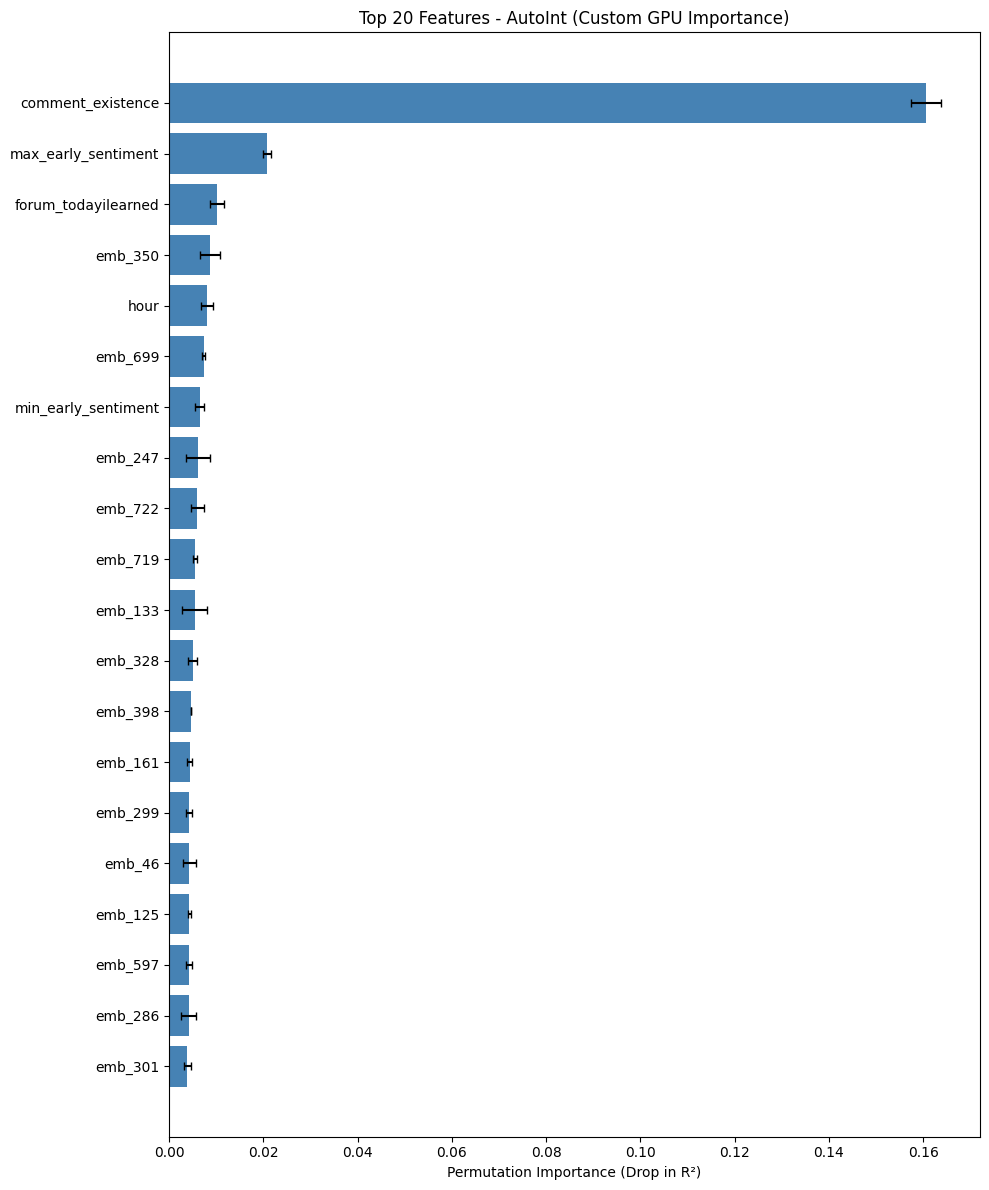


Feature importance completed.


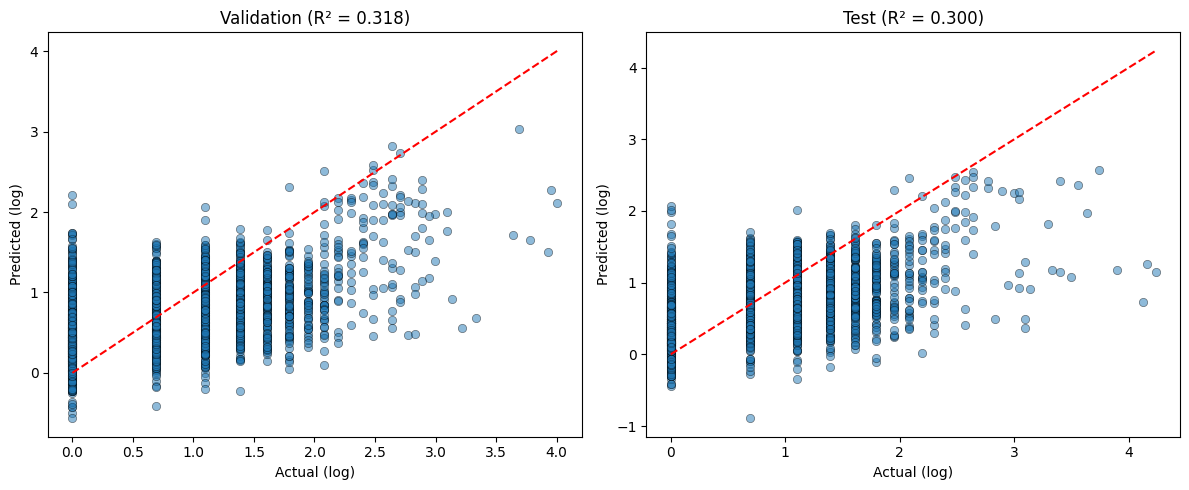

INFO:pytorch_lightning.trainer.connectors.checkpoint_connector:`weights_only` was not set, defaulting to `False`.



Model saved in 'autoint_model' directory
Results saved as 'autoint_results.pkl'

DIAGNOSTICS
Train size: 14200
Val size: 3043
Test size: 3044
Number of features: 783
Target mean (log): 0.6298
Target std (log): 0.7243


In [9]:
print("\nPreparing for permutation importance (GPU batched)...")

# Helper: batched prediction on numpy arrays
def predict_batched(model, X_numpy, batch_size=256):
    """Predict on numpy array in batches, return numpy predictions."""
    n_samples = X_numpy.shape[0]
    preds = []
    for start in range(0, n_samples, batch_size):
        end = min(start + batch_size, n_samples)
        batch_df = pd.DataFrame(X_numpy[start:end], columns=X_train.columns)
        batch_pred_df = model.predict(batch_df)
        preds.append(batch_pred_df[pred_col].values)
    return np.concatenate(preds)

def permutation_importance_gpu(model_wrapper, X, y, n_repeats=5, batch_size=256, random_state=42):
    """Manual permutation importance – loop over features, each with batched prediction."""
    rng = np.random.RandomState(random_state)
    # Baseline R²
    y_pred_base = predict_batched(model_wrapper, X, batch_size)
    base_r2 = r2_score(y, y_pred_base)
    print(f"Baseline R²: {base_r2:.4f}")

    n_features = X.shape[1]
    imp_mean = np.zeros(n_features)
    imp_std = np.zeros(n_features)

    for feat_idx in range(n_features):
        scores = []
        for _ in range(n_repeats):
            X_perm = X.copy()
            X_perm[:, feat_idx] = rng.permutation(X_perm[:, feat_idx])
            y_pred_perm = predict_batched(model_wrapper, X_perm, batch_size)
            r2_perm = r2_score(y, y_pred_perm)
            scores.append(base_r2 - r2_perm)   # drop in R²
        imp_mean[feat_idx] = np.mean(scores)
        imp_std[feat_idx] = np.std(scores)

        if (feat_idx + 1) % 50 == 0:
            print(f"Processed {feat_idx+1}/{n_features} features")

    return imp_mean, imp_std

# Sample validation set to speed up (adjust size as needed)
sample_size = min(2000, len(X_val))
print(f"Using {sample_size} samples for permutation importance (out of {len(X_val)})")
rng = np.random.RandomState(RANDOM_STATE)
sample_indices = rng.choice(len(X_val), sample_size, replace=False)
X_val_sample = X_val.values[sample_indices]
y_val_sample = y_val.values[sample_indices]

print(f"Computing importance on {X_val_sample.shape[0]} samples, {X_val_sample.shape[1]} features...")
imp_means, imp_stds = permutation_importance_gpu(
    tabular_model,
    X_val_sample,
    y_val_sample,
    n_repeats=3,          # Reduce to 3 for speed, increase if needed
    batch_size=256,
    random_state=RANDOM_STATE
)

# ==========================================
# 6. Feature importance results & plotting
# ==========================================
imp_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': imp_means,
    'StdDev': imp_stds
}).sort_values('Importance', ascending=False).head(20)

plt.figure(figsize=(10, 12))
plt.barh(imp_df['Feature'][::-1], imp_df['Importance'][::-1],
         xerr=imp_df['StdDev'][::-1], color='steelblue', capsize=3)
plt.xlabel('Permutation Importance (Drop in R²)')
plt.title('Top 20 Features - AutoInt (Custom GPU Importance)')
plt.tight_layout()
plt.show()

print("\nFeature importance completed.")

# ==========================================
# 7. Prediction vs Actual plots
# ==========================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.scatter(y_val, y_val_pred, alpha=0.5, edgecolors='k', linewidth=0.5)
ax1.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--')
ax1.set_xlabel('Actual (log)')
ax1.set_ylabel('Predicted (log)')
ax1.set_title(f'Validation (R² = {r2_val:.3f})')

ax2.scatter(y_test, y_test_pred, alpha=0.5, edgecolors='k', linewidth=0.5)
ax2.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
ax2.set_xlabel('Actual (log)')
ax2.set_ylabel('Predicted (log)')
ax2.set_title(f'Test (R² = {r2_test:.3f})')
plt.tight_layout()
plt.show()

# ==========================================
# 8. Save model and results
# ==========================================
tabular_model.save_model("autoint_model")
print("\nModel saved in 'autoint_model' directory")

test_results_df = test_df.copy()
test_results_df['predicted'] = y_test_pred
test_results_df['actual'] = y_test
test_results_df.to_csv('test_predictions.csv', index=False)

results = {
    'r2_validation': float(r2_val),
    'r2_test': float(r2_test),
    'feature_importances': imp_df.to_dict(),
    'prediction_column': pred_col
}
joblib.dump(results, 'autoint_results.pkl')
print("Results saved as 'autoint_results.pkl'")

print("\n" + "="*50)
print("DIAGNOSTICS")
print("="*50)
print(f"Train size: {len(train_df)}")
print(f"Val size: {len(val_df)}")
print(f"Test size: {len(test_df)}")
print(f"Number of features: {len(X_train.columns)}")
print(f"Target mean (log): {y.mean():.4f}")
print(f"Target std (log): {y.std():.4f}")

In [1]:
!pip install -U "pytorch_tabular[extra]"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 68.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.9/79.9 MB 22.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.3/857.3 kB 62.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 61.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.1/16.1 MB 95.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 165.8/165.8 kB 18.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 159.8/159.8 kB 17.5 MB/s eta 0:00:00
  Attempting uninstall: wandb
    Found existing installation: wandb 0.25.1
    Uninstalling wandb-0.25.1:
      Successfully uninstalled wandb-0.25.1
